# Vitor Manzano Villela Dias - 24014721
# Renan Martins Lother - 24

Construir um pipeline completo de classificação para o dataset CIFAR-10 (imagens 32×32 RGB, 10 classes), in-
cluindo pré-processamento, divisão treino/validação/teste com semente fixa, validação para melhoria de de-
sempenho, treinamento de uma CNN e avaliação final. O uso de Inteligência Artificial generativa para a resolução
do problema será penalizado na nota da atividade.

1. Leitura e organização do dataset df_gen
Baixe/carregue o CIFAR-10 usando a API da biblioteca escolhida. Mostre: 10 amostras aleatórias (classe e miniaturas), contagem por classe e forma dos dados.

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms
from torch.utils.data import Subset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from collections import Counter

In [ ]:
random_state = 2025
np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

In [ ]:
dataset = torchvision.datasets.CIFAR10('/content/', train=True, download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [00:02<00:00, 65.8MB/s]


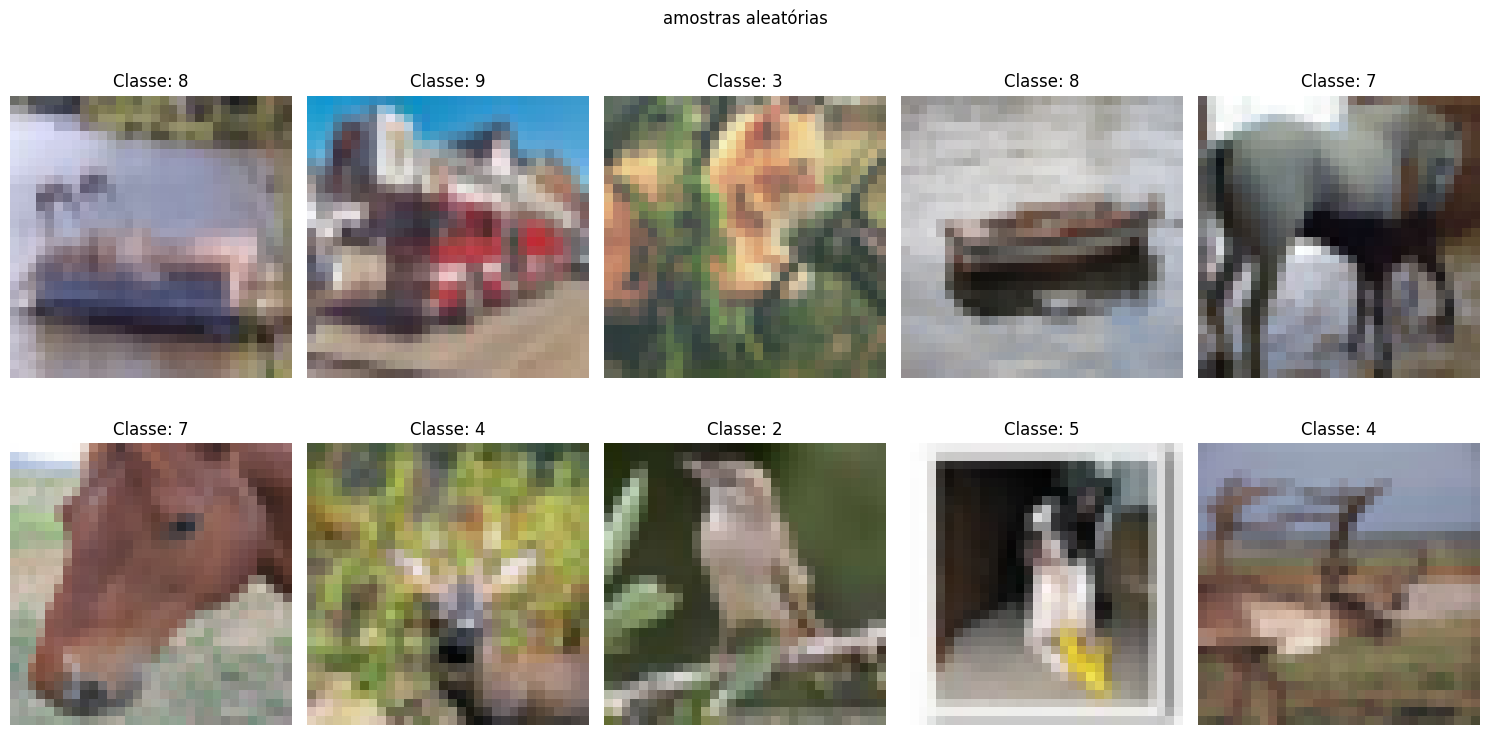

In [ ]:
indices_aleatorios = np.random.choice(len(dataset), size=10, replace=False)
amostras_aleatorias = [dataset[i] for i in indices_aleatorios]

fig, axs = plt.subplots(2, 5, figsize=(15, 8))
for ax, (img, label) in zip(axs.flatten(), amostras_aleatorias):
  ax.imshow(img.permute(1, 2, 0))
  ax.set_title(f"Classe: {label}")
  ax.axis('off')

plt.suptitle("amostras aleatórias")
plt.tight_layout()
plt.show()

In [ ]:
quantidade = Counter(dataset.targets)
print(quantidade)

Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})


In [ ]:
print("Shape: ", dataset.data.shape)
print("Total de amostras: ", len(dataset))
print("Shape da imagem: ", dataset.data[0].shape)

Shape:  (50000, 32, 32, 3)
Total de amostras:  50000
Shape da imagem:  (32, 32, 3)


2. Pré-processamento e data augmentation:

Normalize as imagens para [0,1] ou padronize por canal (média e desvio do CIFAR-10). Recomenda-se augmentação leve para o conjunto de treino: RandomCrop(32, padding=4) e RandomHorizontalFlip(), podendo
incluir ColorJitter moderado.

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
])

In [ ]:
eval_transform = transforms.Compose([
    transforms.ToTensor(),
])

3. Divisão dos Dados em treino/validação/teste
Realize a divisão estratificada, preservando a proporção de classes. Registre a semente (2025) na função de split
e nos geradores de lotes. Demonstre, em tabela, o número de amostras por classe em cada partição.

In [ ]:
dataset_train = torchvision.datasets.CIFAR10('/content/', train=True, download=True, transform=train_transform)
dataset_eval = torchvision.datasets.CIFAR10('/content/', train=True, download=True, transform=eval_transform)

In [ ]:
print("dataset_train:", len(dataset_train), "amostras (com augmentation)")
print("dataset_eval :", len(dataset_eval), "amostras (sem augmentation)")

In [ ]:
indices = np.arange(len(dataset_eval))
labels = dataset_eval.targets

idx_trainval, idx_test = train_test_split(
    indices,
    test_size=0.15,
    stratify=labels,
    random_state=random_state
)

print("Treino+Val:", len(idx_trainval))
print("Teste     :", len(idx_test))

In [ ]:
labels_trainval = [labels[i] for i in idx_trainval]

idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=7500/42500,
    stratify=labels_trainval,
    random_state=random_state
)

print("Treino:", len(idx_train))
print("Val   :", len(idx_val))
print("Teste :", len(idx_test))

In [ ]:
# Tabela: número de amostras por classe em cada partição
classes = dataset_train.classes

def contar(idx_list):
    return Counter([labels[i] for i in idx_list])

c_train = contar(idx_train)
c_val   = contar(idx_val)
c_test  = contar(idx_test)

tabela = pd.DataFrame({
    'Classe':   classes,
    'Treino':   [c_train[i] for i in range(10)],
    'Validação':[c_val[i]   for i in range(10)],
    'Teste':    [c_test[i]  for i in range(10)],
})
tabela.loc['Total'] = ['—', tabela['Treino'].sum(), tabela['Validação'].sum(), tabela['Teste'].sum()]
tabela